# Statistical Audit of pandas-dev/pandas



## Member Information
- **Name:** Ahmad Aqil Fadria
- **Role:** Data Engineer

---

# Research Questions

1. Berapa perkiraan probabilitas bahwa sebuah pull request akan digabungkan ke pandas-dev/pandas?

2. Apakah rata-rata durasi penutupan issue telah berubah secara signifikan setelah rilis utama pandas?

3. Berapa probabilitas bahwa issue yang dipilih secara acak membutuhkan waktu lebih dari 30 hari untuk ditutup?

---

# AI Usage Disclosure

**Member:** Ahmad Aqil Fadria — Data Engineer  
**Tools used:** ChatGPT

| Task | Tool | Prompt Summary | Output Modified? |
|---|---|---|---|
| GitHub API collection workflow | ChatGPT | GitHub issues API data collection | Yes |
| EDA notebook structure | ChatGPT | Statistical EDA notebook structure | Yes |

**Written entirely without AI:**
- Interpretation markdown cells
- EDA conclusions

---

# Import Libraries

In [7]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# GitHub API Configuration

Pada bagian ini dilakukan konfigurasi repository GitHub
dan endpoint API yang digunakan untuk mengambil data
issue dan pull request dari repository pandas-dev/pandas.

Konfigurasi ini digunakan sebagai dasar proses pengambilan data
menggunakan GitHub REST API sehingga notebook dapat
mengakses data repository secara otomatis.


In [ ]:
OWNER = "pandas-dev"
REPO = "pandas"

BASE_URL = f"https://api.github.com/repos/{OWNER}/{REPO}/issues"

# GitHub Personal Access Token
TOKEN = "ghp_xxxxxxxxxxxxxxxxxxxxxxxxxxxx"

headers = {
    "Authorization": f"token {TOKEN}",
    "Accept": "application/vnd.github+json"
}


# Collect Issues Data

Pada bagian ini dilakukan proses pengambilan data issue
dari GitHub REST API pada repository pandas-dev/pandas.

Data yang dikumpulkan mencakup issue dengan status
open maupun closed yang nantinya akan digunakan
untuk proses cleaning, exploratory data analysis (EDA),
dan analisis statistik pada tahap berikutnya.


In [9]:
all_issues = []

for page in range(1, 51):

    url = (
        f"{BASE_URL}"
        f"?state=all&per_page=100&page={page}"
    )

    response = requests.get(
        url,
        headers=headers
    )


    if response.status_code != 200:
        print(f"Error collecting page {page}")
        break

    data = response.json()

    if len(data) == 0:
        break

    all_issues.extend(data)

    
    print("Total raw data:",
      len(all_issues))

Total raw data: 100
Total raw data: 200
Total raw data: 300
Total raw data: 400
Total raw data: 500
Total raw data: 600
Total raw data: 700
Total raw data: 800
Total raw data: 900
Total raw data: 1000
Total raw data: 1100
Total raw data: 1200
Total raw data: 1300
Total raw data: 1400
Total raw data: 1500
Total raw data: 1600
Total raw data: 1700
Total raw data: 1800
Total raw data: 1900
Total raw data: 2000
Total raw data: 2100
Total raw data: 2200
Total raw data: 2300
Total raw data: 2400
Total raw data: 2500
Total raw data: 2600
Total raw data: 2700
Total raw data: 2800
Total raw data: 2900
Total raw data: 3000
Total raw data: 3100
Total raw data: 3200
Total raw data: 3300
Total raw data: 3400
Total raw data: 3500
Total raw data: 3600
Total raw data: 3700
Total raw data: 3800
Total raw data: 3900
Total raw data: 4000
Total raw data: 4100
Total raw data: 4200
Total raw data: 4300
Total raw data: 4400
Total raw data: 4500
Total raw data: 4600
Total raw data: 4700
Total raw data: 4800
T

# Convert to DataFrame

Data hasil pengambilan dari GitHub API masih berbentuk
JSON sehingga perlu dikonversi menjadi pandas DataFrame.

Proses ini dilakukan agar data lebih mudah dibaca,
dibersihkan, dianalisis, dan divisualisasikan
pada tahap selanjutnya.


In [10]:
df = pd.DataFrame(all_issues)

print(df.shape)

(5000, 37)


# Save Raw Dataset

Dataset asli hasil pengambilan dari GitHub API
disimpan tanpa perubahan ke dalam folder raw.

Penyimpanan data mentah ini bertujuan untuk menjaga
keaslian data sebelum dilakukan proses cleaning
dan preprocessing lebih lanjut.


In [11]:
df.to_csv("../data/raw/issues_raw.csv", index=False)

print("Raw dataset saved.")

Raw dataset saved.


# Filter True Issues

Endpoint issues pada GitHub juga dapat mengandung
data pull request sehingga perlu dilakukan proses filtering.

Pada bagian ini dilakukan pemisahan data agar
dataset hanya berisi issue yang sebenarnya
dan tidak mencampurkan data pull request.


In [12]:
# ============================================================
# CLEAN ISSUE DATA
# ============================================================

issues_df = df.copy()

# ambil hanya closed
issues_df = issues_df[
    issues_df["state"] == "closed"
].copy()

print(issues_df.shape)

(4377, 37)


# Select Important Columns

Pada bagian ini dipilih beberapa kolom penting
yang relevan untuk kebutuhan analisis statistik.

Pemilihan kolom dilakukan agar dataset menjadi
lebih ringkas, mudah diproses, dan fokus
pada variabel yang akan dianalisis.


In [13]:
issues_df = issues_df[
    [
        "id",
        "number",
        "title",
        "state",
        "created_at",
        "closed_at",
        "comments"
    ]
]

# Datetime Conversion

Kolom yang berisi informasi waktu dikonversi
ke format datetime pada pandas.

Proses ini dilakukan agar data waktu dapat
digunakan untuk analisis durasi, perhitungan selisih waktu,
serta kebutuhan analisis statistik lainnya.


In [14]:
issues_df["created_at"] = pd.to_datetime(
    issues_df["created_at"]
)

issues_df["closed_at"] = pd.to_datetime(
    issues_df["closed_at"]
)

# Feature Engineering

Pada bagian ini dilakukan pembuatan variabel baru
yang dibutuhkan untuk analisis statistik.

Variabel tambahan dibuat berdasarkan data yang sudah ada
agar proses analisis, visualisasi, dan interpretasi data
dapat dilakukan dengan lebih mudah.


In [15]:
issues_df["close_duration_days"] = (
    issues_df["closed_at"] - issues_df["created_at"]
).dt.days

issues_df["is_closed"] = 1

# Save Clean Dataset

Dataset yang telah melalui proses cleaning
dan preprocessing disimpan ke dalam folder clean.

Dataset bersih ini nantinya akan digunakan
pada tahap analisis statistik berikutnya
seperti estimation, inference, hypothesis testing,
dan simulation.


In [16]:
issues_df.to_csv(
    "../data/clean/dataset.csv",
    index=False
)

# Dataset Overview

Pada bagian ini ditampilkan gambaran umum
mengenai dataset yang telah dibersihkan.

Overview dataset digunakan untuk melihat
struktur data, jumlah data, tipe variabel,
serta memastikan data siap digunakan
untuk proses analisis selanjutnya.


In [17]:
issues_df.head()

,id,number,title,state,created_at,closed_at,comments,close_duration_days,is_closed
8,4539481199,65743,PERF: Fix performance regression in to_julian_...,closed,2026-05-28 09:58:29+00:00,2026-05-28 16:40:32+00:00,1,0,1
14,4526140043,65736,CI: Bump pixi to 0.69,closed,2026-05-26 17:26:40+00:00,2026-05-26 18:33:46+00:00,1,0,1
18,4517506050,65732,Backport PR #65731 on branch 3.0.x (DOC: start...,closed,2026-05-25 14:10:22+00:00,2026-05-26 13:06:13+00:00,0,0,1
19,4517400089,65731,DOC: start 3.0.4 whatsnew notes,closed,2026-05-25 13:53:44+00:00,2026-05-25 14:09:52+00:00,0,0,1
21,4516764518,65729,Bump github/codeql-action from 4.35.5 to 4.36.0,closed,2026-05-25 12:05:11+00:00,2026-05-26 16:16:53+00:00,0,1,1


In [18]:
issues_df.info()

<class 'pandas.DataFrame'>
Index: 4377 entries, 8 to 4999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   id                   4377 non-null   int64              
 1   number               4377 non-null   int64              
 2   title                4377 non-null   str                
 3   state                4377 non-null   str                
 4   created_at           4377 non-null   datetime64[us, UTC]
 5   closed_at            4377 non-null   datetime64[us, UTC]
 6   comments             4377 non-null   int64              
 7   close_duration_days  4377 non-null   int64              
 8   is_closed            4377 non-null   int64              
dtypes: datetime64[us, UTC](2), int64(5), str(2)
memory usage: 342.0 KB


In [19]:
issues_df.describe()

,id,number,comments,close_duration_days,is_closed
count,4.377000e+03,4377.000000,4377.000000,4377.000000,4377.0
mean,3.622703e+09,63138.891707,2.382682,19.374457,1.0
std,4.598165e+08,1420.650696,4.171046,49.050871,0.0
min,2.782675e+09,60705.000000,0.000000,0.000000,1.0
25%,3.250176e+09,61919.000000,1.000000,0.000000,1.0
50%,3.630603e+09,63127.000000,1.000000,1.000000,1.0
75%,4.008116e+09,64358.000000,3.000000,13.000000,1.0
max,4.539481e+09,65743.000000,108.000000,474.000000,1.0


# Missing Values Analysis

Pada bagian ini dilakukan pengecekan
terhadap missing values pada dataset.

Analisis ini bertujuan untuk memastikan
tidak terdapat data yang kosong atau tidak lengkap
yang dapat memengaruhi hasil analisis statistik.


In [20]:
issues_df.isnull().sum()

id                     0
number                 0
title                  0
state                  0
created_at             0
closed_at              0
comments               0
close_duration_days    0
is_closed              0
dtype: int64

# Visualization: Closing Duration Distribution

Visualisasi histogram ini menunjukkan distribusi
durasi waktu penutupan issue dalam satuan hari.

Berdasarkan histogram yang dihasilkan,
distribusi data cenderung skewed ke kanan (right-skewed),
yang menunjukkan bahwa sebagian besar issue
ditutup dalam waktu relatif singkat,
namun terdapat beberapa issue yang membutuhkan
waktu jauh lebih lama untuk diselesaikan.

Pola distribusi seperti ini umum ditemukan
pada data repository open-source karena
tidak semua issue memiliki tingkat kesulitan yang sama.


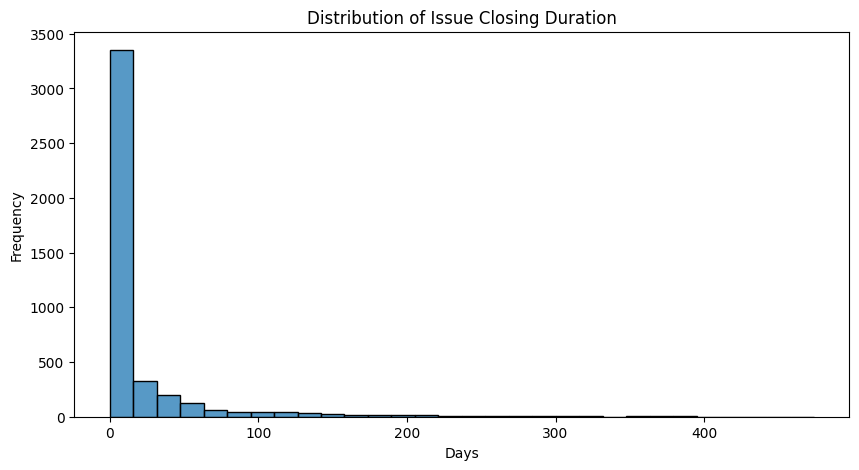

In [21]:
plt.figure(figsize=(10, 5))

sns.histplot(
    issues_df["close_duration_days"],
    bins=30
)

plt.title("Distribution of Issue Closing Duration")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

# Visualization: Issue Status Count

Visualisasi ini menunjukkan perbandingan jumlah
issue berdasarkan statusnya, yaitu open dan closed.

Berdasarkan hasil visualisasi, jumlah issue dengan status
closed lebih banyak dibandingkan issue dengan status open.
Hal ini menunjukkan bahwa sebagian besar issue pada
repository pandas-dev/pandas telah berhasil diselesaikan.

Perbandingan jumlah issue open dan closed dapat memberikan
gambaran mengenai tingkat aktivitas dan efektivitas
pengelolaan issue dalam repository open-source.



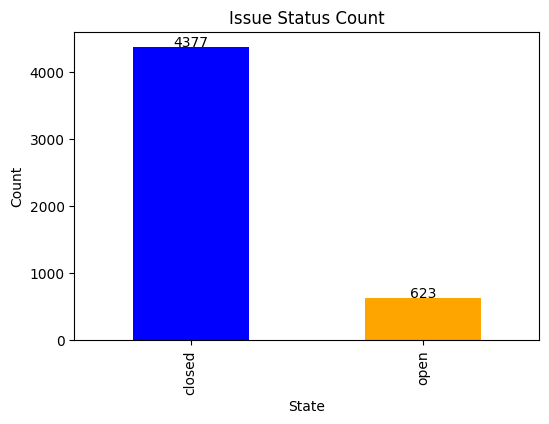

In [37]:
plt.figure(figsize=(6, 4))

ax = df["state"].value_counts().plot(
    kind="bar",
    color=["blue", "orange"]
)

# menampilkan jumlah di atas batang
for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width() / 2,
        i.get_height() + 5,
        str(int(i.get_height())),
        ha='center'
    )

plt.title("Issue Status Count")
plt.xlabel("State")
plt.ylabel("Count")

plt.show()

# Visualization: Issues Created Over Time

This vis# Visualization: Issues Created Over Time

Visualisasi line chart ini menunjukkan tren jumlah
issue yang dibuat dari waktu ke waktu berdasarkan periode bulan.

Data created_at dikonversi menjadi format year-month
agar jumlah issue dapat dikelompokkan per bulan
dan divisualisasikan dalam bentuk time series.

Melalui grafik ini dapat diamati pola aktivitas repository,
seperti peningkatan maupun penurunan jumlah issue
pada periode tertentu.

Fluktuasi jumlah issue dapat menunjukkan:

* tingkat aktivitas pengguna repository
* peningkatan penggunaan project
* adanya update atau perubahan besar pada project
* peningkatan laporan bug atau request fitur baru

Analisis tren waktu seperti ini membantu memahami
perkembangan aktivitas repository secara keseluruhan.
ualization shows issue activity trends over time.

C:\Users\HELLO\AppData\Local\Temp\ipykernel_8744\248647077.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


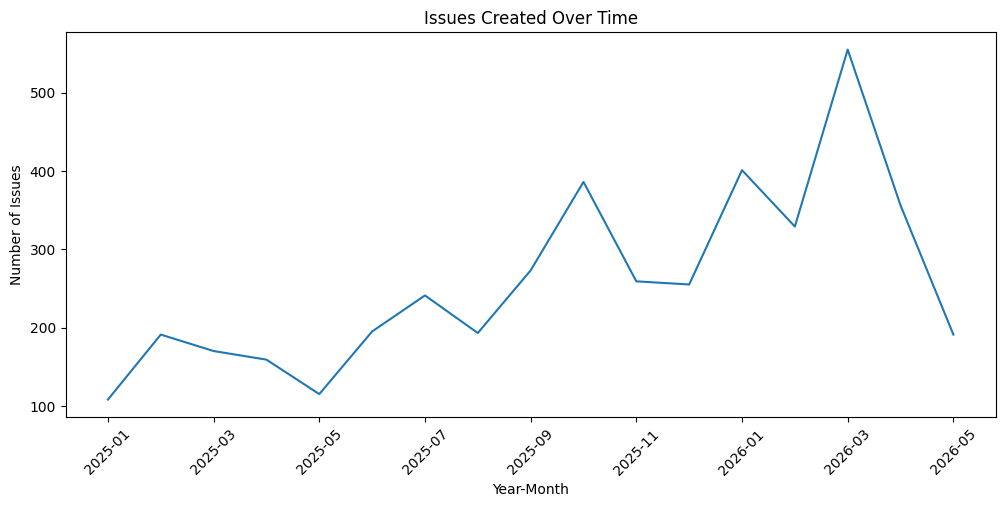

In [23]:
issues_df["year_month"] = (
    issues_df["created_at"]
    .dt.to_period("M")
    .astype(str)
)

monthly_issues = (
    issues_df["year_month"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

monthly_issues.plot()

plt.title("Issues Created Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Issues")

plt.xticks(rotation=45)

plt.show()

# Variable Selection

Pada bagian ini dipilih beberapa variabel
yang akan digunakan untuk proses analisis statistik
pada tahap selanjutnya.

Pemilihan variabel dilakukan berdasarkan
relevansi data terhadap research question
dan kebutuhan analisis seperti estimation,
inference, hypothesis testing, dan simulation.


In [39]:
variable_selection = pd.DataFrame({
    "Variable": [
        "is_closed",
        "close_duration_days",
        "comments"
    ],

    "Description": [
        "Status issue closed",
        "Durasi penutupan issue",
        "Jumlah komentar issue"
    ],

    "Statistical Usage": [
        "Bernoulli Estimation",
        "Confidence Interval & Hypothesis Testing",
        "Poisson Analysis"
    ]
})

variable_selection

,Variable,Description,Statistical Usage
0,is_closed,Status issue closed,Bernoulli Estimation
1,close_duration_days,Durasi penutupan issue,Confidence Interval & Hypothesis Testing
2,comments,Jumlah komentar issue,Poisson Analysis


# Pull Request Data Collection

Pada bagian ini dilakukan proses pengambilan
data pull request dari repository pandas-dev/pandas
menggunakan GitHub REST API.

Dataset pull request ini akan digunakan
untuk analisis statistik pada tahap berikutnya,
seperti:

* estimasi probabilitas pull request di-merge
* Bernoulli Maximum Likelihood Estimation (MLE)
* confidence interval
* hypothesis testing

Data yang dikumpulkan mencakup informasi
status pull request, waktu pembuatan,
waktu merge, dan waktu penutupan pull request.


In [ ]:
# ============================================================
# PULL REQUEST DATA COLLECTION
# ============================================================

all_prs = []

# endpoint pull requests
PR_URL = (
    f"https://api.github.com/repos/"
    f"{OWNER}/{REPO}/pulls"
)

# mengambil beberapa halaman data
for page in range(1, 11):

    url = (
        f"{PR_URL}"
        f"?state=all&per_page=100&page={page}"
    )

    response = requests.get(
        url,
        headers=headers
    )

    # cek request berhasil
    if response.status_code != 200:
        print(f"Error collecting page {page}")
        print(response.text)
        break

    data = response.json()

    # berhenti jika data habis
    if len(data) == 0:
        break

    all_prs.extend(data)

    print(f"Collected PR page {page}")

print("Total Pull Requests:",
      len(all_prs))

ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

# Convert Pull Request Data to DataFrame

This section converts the collected pull request
JSON data into a pandas DataFrame for processing
and analysis.

In [ ]:
pr_df = pd.DataFrame(all_prs)

print(pr_df.shape)

pr_df.head()

(500, 36)


,url,id,node_id,html_url,diff_url,patch_url,issue_url,number,state,locked,...,review_comment_url,comments_url,statuses_url,head,base,_links,author_association,auto_merge,assignee,active_lock_reason
0,https://api.github.com/repos/pandas-dev/pandas...,3765970027,PR_kwDOAA0YD87geCRr,https://github.com/pandas-dev/pandas/pull/65751,https://github.com/pandas-dev/pandas/pull/6575...,https://github.com/pandas-dev/pandas/pull/6575...,https://api.github.com/repos/pandas-dev/pandas...,65751,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,"{'label': 'jbrockmendel:depr-ragged', 'ref': '...","{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,MEMBER,None,None,None
1,https://api.github.com/repos/pandas-dev/pandas...,3765926178,PR_kwDOAA0YD87gd3ki,https://github.com/pandas-dev/pandas/pull/65750,https://github.com/pandas-dev/pandas/pull/6575...,https://github.com/pandas-dev/pandas/pull/6575...,https://api.github.com/repos/pandas-dev/pandas...,65750,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,"{'label': 'jbrockmendel:bug-where', 'ref': 'bu...","{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,MEMBER,None,None,None
2,https://api.github.com/repos/pandas-dev/pandas...,3765856975,PR_kwDOAA0YD87gdmrP,https://github.com/pandas-dev/pandas/pull/65749,https://github.com/pandas-dev/pandas/pull/6574...,https://github.com/pandas-dev/pandas/pull/6574...,https://api.github.com/repos/pandas-dev/pandas...,65749,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,"{'label': 'jbrockmendel:bug-ragged', 'ref': 'b...","{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,MEMBER,None,None,None
3,https://api.github.com/repos/pandas-dev/pandas...,3765839234,PR_kwDOAA0YD87gdiWC,https://github.com/pandas-dev/pandas/pull/65748,https://github.com/pandas-dev/pandas/pull/6574...,https://github.com/pandas-dev/pandas/pull/6574...,https://api.github.com/repos/pandas-dev/pandas...,65748,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,"{'label': 'jbrockmendel:bug-unstack', 'ref': '...","{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,MEMBER,None,None,None
4,https://api.github.com/repos/pandas-dev/pandas...,3765835619,PR_kwDOAA0YD87gdhdj,https://github.com/pandas-dev/pandas/pull/65747,https://github.com/pandas-dev/pandas/pull/6574...,https://github.com/pandas-dev/pandas/pull/6574...,https://api.github.com/repos/pandas-dev/pandas...,65747,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,{'label': 'jbrockmendel:bug-get_indexer_non_un...,"{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,MEMBER,None,None,None


# Save Raw Pull Request Dataset

This section stores the original pull request dataset
without modification.

Output:
- data/raw/pull_requests_raw.csv

In [ ]:
pr_df.to_csv(
    "../data/raw/pull_requests_raw.csv",
    index=False
)

print("pull_requests_raw.csv saved.")

pull_requests_raw.csv saved.


# Pull Request Data Cleaning

This section cleans the pull request dataset
and selects relevant variables for statistical analysis.

Cleaning includes:
- selecting relevant columns
- datetime conversion
- handling missing values
- feature engineering

In [ ]:
pr_clean = pr_df[
    [
        "id",
        "number",
        "state",
        "created_at",
        "closed_at",
        "merged_at"
    ]
].copy()

print(pr_clean.shape)

pr_clean.head()

(500, 6)


,id,number,state,created_at,closed_at,merged_at
0,3765970027,65751,open,2026-05-29T01:53:15Z,NaN,NaN
1,3765926178,65750,open,2026-05-29T01:40:55Z,NaN,NaN
2,3765856975,65749,open,2026-05-29T01:17:28Z,NaN,NaN
3,3765839234,65748,open,2026-05-29T01:13:09Z,NaN,NaN
4,3765835619,65747,open,2026-05-29T01:12:17Z,NaN,NaN


# Datetime Conversion

This section converts timestamp variables
into datetime format for duration analysis
and statistical computation.

In [ ]:
pr_clean["created_at"] = pd.to_datetime(
    pr_clean["created_at"]
)

pr_clean["closed_at"] = pd.to_datetime(
    pr_clean["closed_at"]
)

pr_clean["merged_at"] = pd.to_datetime(
    pr_clean["merged_at"]
)

# Pull Request Feature Engineering

This section creates additional variables
required for statistical analysis.

Generated variables:
- merged
- review_duration_days

In [ ]:
# merged PR indicator
pr_clean["merged"] = (
    pr_clean["merged_at"].notna()
).astype(int)

# review duration
pr_clean["review_duration_days"] = (
    pr_clean["closed_at"] - pr_clean["created_at"]
).dt.days

pr_clean.head()

,id,number,state,created_at,closed_at,merged_at,merged,review_duration_days
0,3765970027,65751,open,2026-05-29 01:53:15+00:00,NaT,NaT,0,NaN
1,3765926178,65750,open,2026-05-29 01:40:55+00:00,NaT,NaT,0,NaN
2,3765856975,65749,open,2026-05-29 01:17:28+00:00,NaT,NaT,0,NaN
3,3765839234,65748,open,2026-05-29 01:13:09+00:00,NaT,NaT,0,NaN
4,3765835619,65747,open,2026-05-29 01:12:17+00:00,NaT,NaT,0,NaN


# Save Clean Pull Request Dataset

This section exports the cleaned pull request dataset
for use by subsequent statistical analysis layers.

Output:
- data/clean/pr_dataset.csv

In [ ]:
pr_clean.to_csv(
    "../data/clean/pr_dataset.csv",
    index=False
)

print("pr_dataset.csv saved.")

pr_dataset.csv saved.


# Visualization: Pull Request Merge Status

This visualization shows the number of merged
and non-merged pull requests in the repository.

This variable is important for:
- Bernoulli estimation
- merge probability analysis
- confidence interval construction

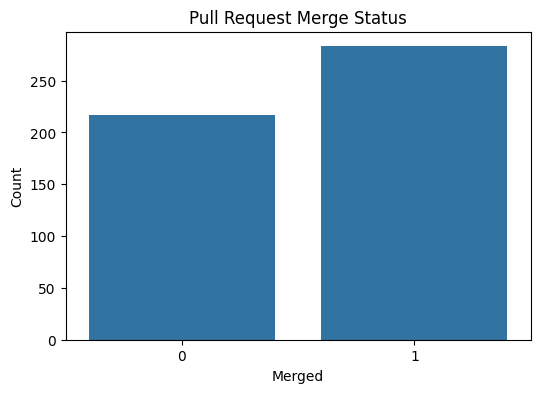

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="merged",
    data=pr_clean
)

plt.title("Pull Request Merge Status")
plt.xlabel("Merged")
plt.ylabel("Count")

plt.show()

# Visualization: Pull Request Review Duration

This visualization explores how long pull requests
take to be reviewed and closed.

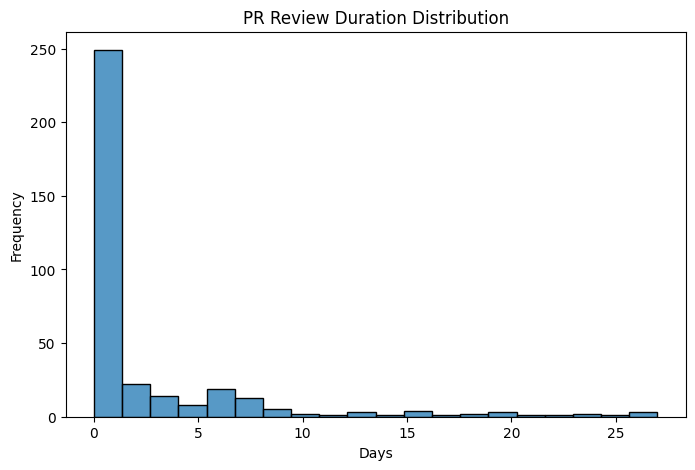

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    pr_clean["review_duration_days"].dropna(),
    bins=20
)

plt.title("PR Review Duration Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

# Summary

This notebook successfully completed the data engineering
workflow for the statistical audit of the pandas-dev/pandas
GitHub repository.

The workflow included:
- collecting GitHub issue data
- collecting pull request data
- storing raw datasets
- cleaning and preprocessing datasets
- feature engineering
- exploratory data analysis (EDA)
- generating statistical visualizations

Datasets generated in this notebook:

Raw datasets:
- data/raw/issues_raw.csv
- data/raw/pull_requests_raw.csv

Clean datasets:
- data/clean/dataset.csv
- data/clean/pr_dataset.csv

Key variables prepared for further statistical analysis:
- issue closing duration
- issue activity frequency
- pull request merge status
- pull request review duration

The cleaned datasets produced in this notebook
will be used by the next analysis layers:
- parameter estimation
- confidence interval construction
- hypothesis testing
- computational simulation

This notebook establishes the foundational data pipeline
required for all subsequent statistical analyses in the project.